In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from sklearn.metrics import confusion_matrix, classification_report

np.random.seed(42)
tf.random.set_seed(42)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.size"] = 11

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (60000, 28, 28, 1)
y_train: (60000,)
X_test : (10000, 28, 28, 1)
y_test : (10000,)


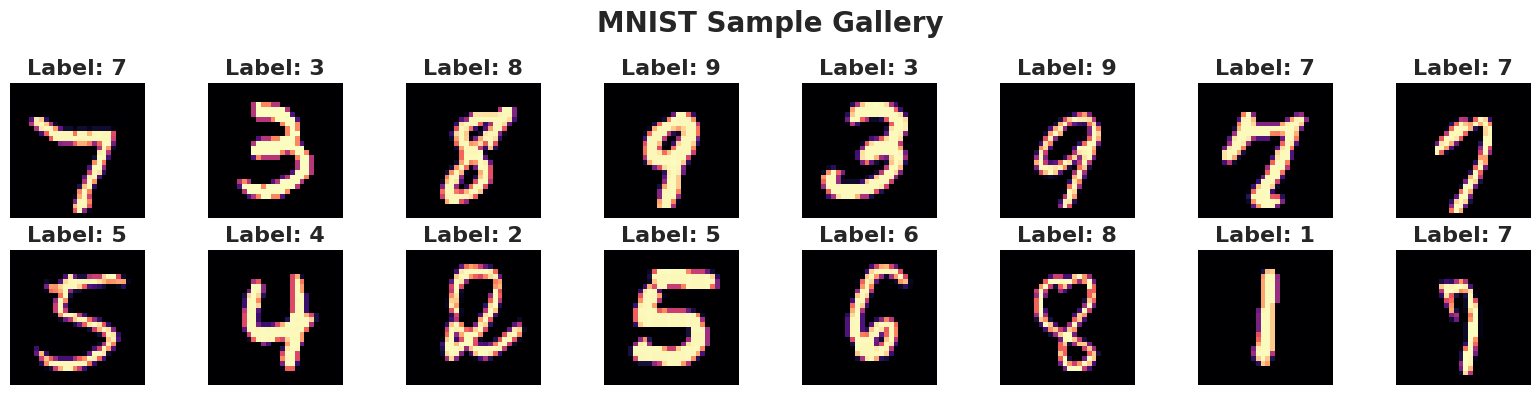

In [3]:
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
sample_ids = np.random.choice(len(X_train), 16, replace=False)

for ax, idx in zip(axes.ravel(), sample_ids):
    ax.imshow(X_train[idx].squeeze(), cmap="magma")
    ax.set_title(f"Label: {y_train[idx]}", fontweight="bold")
    ax.axis("off")

fig.suptitle("MNIST Sample Gallery", fontsize=20, fontweight="bold")
plt.tight_layout()
plt.show()

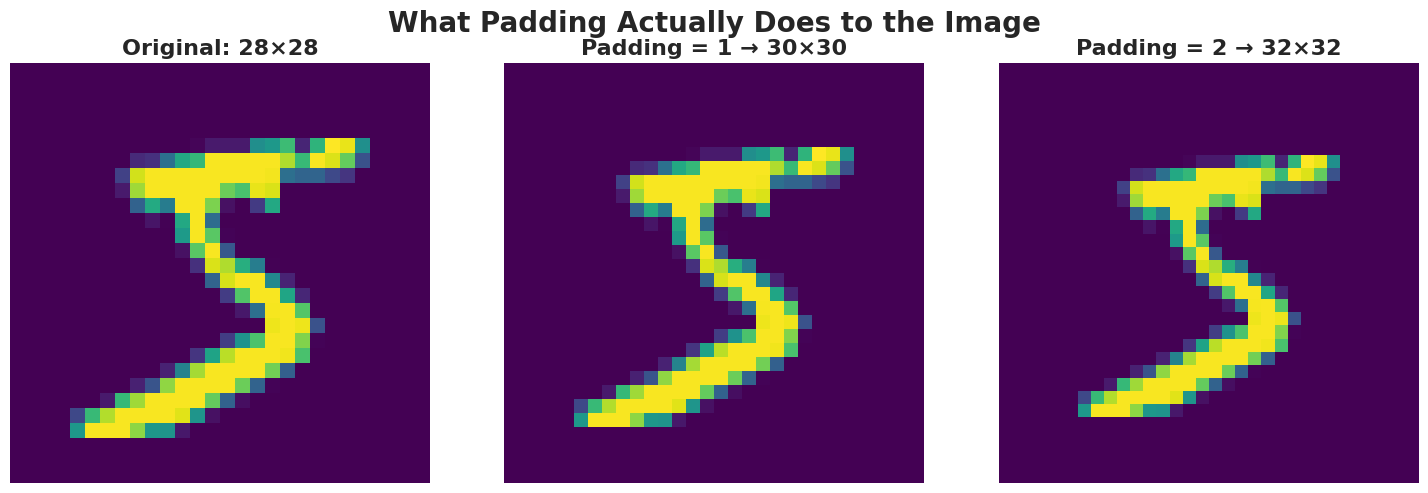

In [4]:
img = X_train[np.where(y_train == 5)[0][0]].squeeze()

pad_1 = np.pad(img, ((1, 1), (1, 1)), mode="constant", constant_values=0)
pad_2 = np.pad(img, ((2, 2), (2, 2)), mode="constant", constant_values=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img, cmap="viridis")
axes[0].set_title("Original: 28×28", fontweight="bold")
axes[1].imshow(pad_1, cmap="viridis")
axes[1].set_title("Padding = 1 → 30×30", fontweight="bold")
axes[2].imshow(pad_2, cmap="viridis")
axes[2].set_title("Padding = 2 → 32×32", fontweight="bold")

for ax in axes:
    ax.set_xticks(np.arange(-0.5, ax.images[0].get_array().shape[1], 4), minor=True)
    ax.set_yticks(np.arange(-0.5, ax.images[0].get_array().shape[0], 4), minor=True)
    ax.grid(which="minor", linewidth=0.5, alpha=0.25)
    ax.axis("off")

fig.suptitle("What Padding Actually Does to the Image", fontsize=20, fontweight="bold")
plt.tight_layout()
plt.show()

In [5]:
def output_size(n, k=3, p=0, s=1):
    return math.floor((n + 2*p - k) / s) + 1

examples = []
for padding_name, p in [("valid", 0), ("same (3×3, s=1)", 1), ("same-style zero pad (s=2)", 1)]:
    for stride in [1, 2]:
        out_size = output_size(28, 3, p, stride)
        examples.append([padding_name, 28, 3, p, stride, out_size])

shape_table = pd.DataFrame(
    examples,
    columns=["Padding idea", "Input N", "Kernel K", "Pad P", "Stride S", "Output N"]
)
shape_table

,Padding idea,Input N,Kernel K,Pad P,Stride S,Output N
0,valid,28,3,0,1,26
1,valid,28,3,0,2,13
2,"same (3×3, s=1)",28,3,1,1,28
3,"same (3×3, s=1)",28,3,1,2,14
4,same-style zero pad (s=2),28,3,1,1,28
5,same-style zero pad (s=2),28,3,1,2,14


In [6]:
input_tensor = keras.Input(shape=(28, 28, 1))

valid_model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(16, (3, 3), padding="valid", strides=(1, 1), activation="relu"),
])

same_model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(16, (3, 3), padding="same", strides=(1, 1), activation="relu"),
])

valid_output = valid_model(X_train[:1], training=False).numpy()
same_output = same_model(X_train[:1], training=False).numpy()

print("VALID output shape:", valid_output.shape)
print("SAME  output shape:", same_output.shape)

comparison = pd.DataFrame({
    "Configuration": ["Input", "VALID padding", "SAME padding"],
    "Height": [28, valid_output.shape[1], same_output.shape[1]],
    "Width": [28, valid_output.shape[2], same_output.shape[2]],
    "Channels / filters": [1, valid_output.shape[3], same_output.shape[3]]
})
comparison

VALID output shape: (1, 26, 26, 16)
SAME  output shape: (1, 28, 28, 16)


,Configuration,Height,Width,Channels / filters
0,Input,28,28,1
1,VALID padding,26,26,16
2,SAME padding,28,28,16


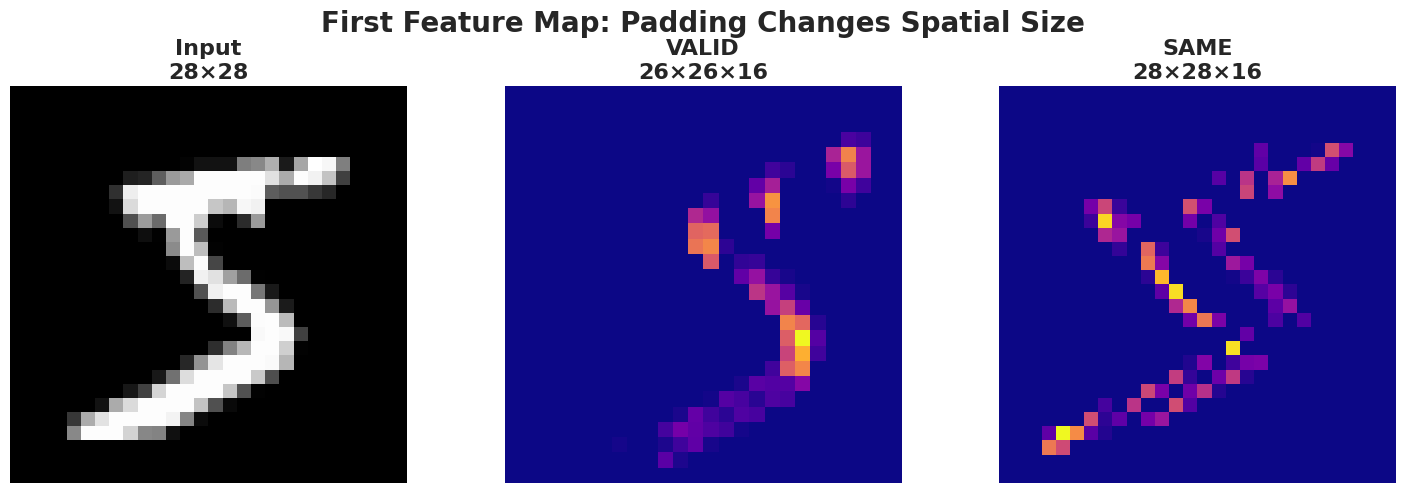

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Input\n28×28", fontweight="bold")

axes[1].imshow(valid_output[0, :, :, 0], cmap="plasma")
axes[1].set_title("VALID\n26×26×16", fontweight="bold")

axes[2].imshow(same_output[0, :, :, 0], cmap="plasma")
axes[2].set_title("SAME\n28×28×16", fontweight="bold")

for ax in axes:
    ax.axis("off")

fig.suptitle("First Feature Map: Padding Changes Spatial Size", fontsize=20, fontweight="bold")
plt.tight_layout()
plt.show()

In [8]:
stride_results = []

for padding in ["valid", "same"]:
    for stride in [1, 2, 3]:
        m = keras.Sequential([
            keras.Input(shape=(28, 28, 1)),
            layers.Conv2D(8, (3, 3), padding=padding, strides=(stride, stride), activation="relu")
        ])
        y = m(X_train[:1], training=False)
        stride_results.append({
            "Padding": padding,
            "Stride": f"{stride}×{stride}",
            "Output H": int(y.shape[1]),
            "Output W": int(y.shape[2]),
            "Channels": int(y.shape[3]),
            "Spatial cells": int(y.shape[1] * y.shape[2])
        })

stride_df = pd.DataFrame(stride_results)
stride_df

,Padding,Stride,Output H,Output W,Channels,Spatial cells
0,valid,1×1,26,26,8,676
1,valid,2×2,13,13,8,169
2,valid,3×3,9,9,8,81
3,same,1×1,28,28,8,784
4,same,2×2,14,14,8,196
5,same,3×3,10,10,8,100


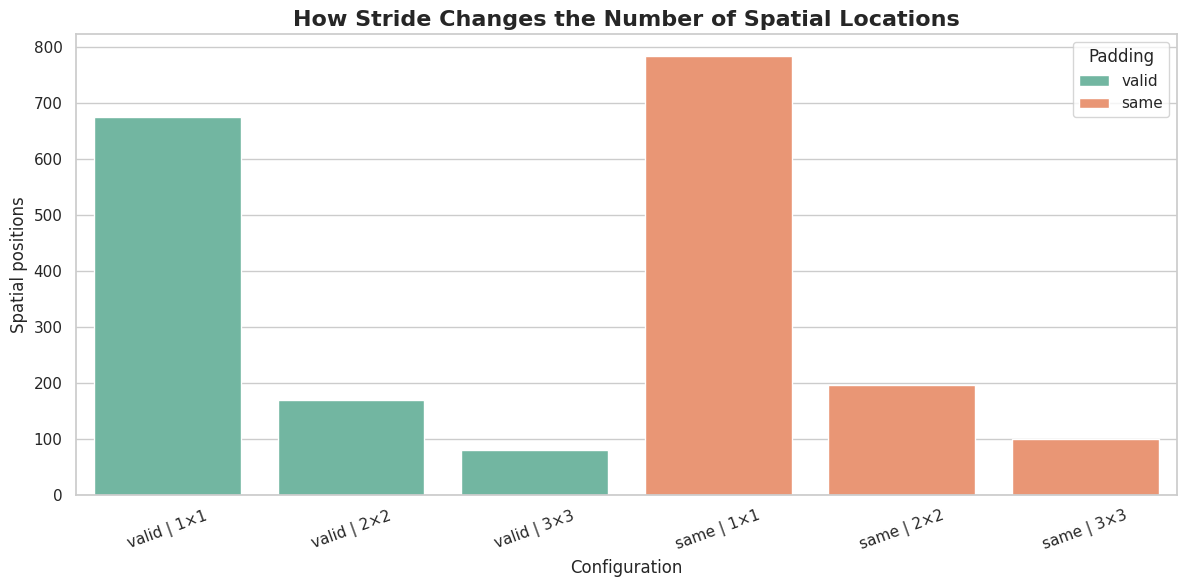

In [9]:
plot_df = stride_df.copy()
plot_df["Label"] = plot_df["Padding"] + " | " + plot_df["Stride"]

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=plot_df, x="Label", y="Spatial cells", hue="Padding", palette="Set2")
plt.title("How Stride Changes the Number of Spatial Locations", fontweight="bold")
plt.xlabel("Configuration")
plt.ylabel("Spatial positions")
plt.xticks(rotation=20)
plt.legend(title="Padding")
plt.tight_layout()
plt.show()

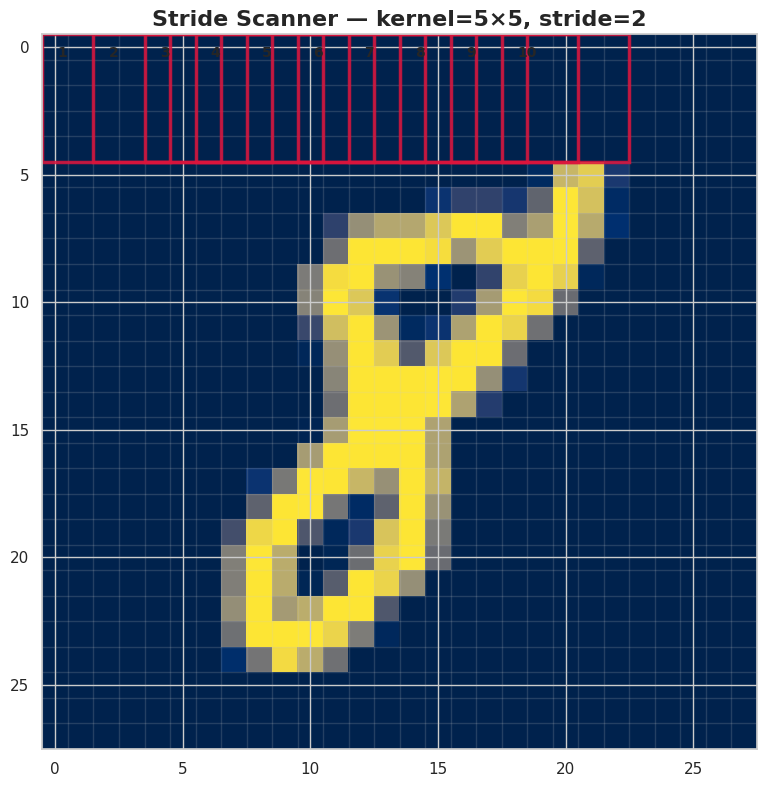

In [10]:
from matplotlib.patches import Rectangle

def show_stride_scan(image, kernel_size=3, stride=1, max_steps=12):
    image = image.squeeze()
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image, cmap="cividis", origin="upper")

    h, w = image.shape
    positions = []
    for r in range(0, h - kernel_size + 1, stride):
        for c in range(0, w - kernel_size + 1, stride):
            positions.append((r, c))

    for step, (r, c) in enumerate(positions[:max_steps], start=1):
        rect = Rectangle(
            (c - 0.5, r - 0.5),
            kernel_size,
            kernel_size,
            fill=False,
            linewidth=2.5,
            edgecolor="crimson",
            alpha=0.85
        )
        ax.add_patch(rect)
        ax.text(c + 0.1, r + 0.4, str(step), fontsize=10, fontweight="bold")

    ax.set_title(f"Stride Scanner — kernel={kernel_size}×{kernel_size}, stride={stride}", fontweight="bold")
    ax.set_xticks(np.arange(-0.5, w, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, h, 1), minor=True)
    ax.grid(which="minor", alpha=0.18)
    ax.set_xlim(-0.5, w - 0.5)
    ax.set_ylim(h - 0.5, -0.5)
    plt.tight_layout()
    plt.show()

small_digit = X_train[np.where(y_train == 8)[0][0]]
show_stride_scan(small_digit, kernel_size=5, stride=2, max_steps=10)

In [11]:
def make_shape_probe(padding="same", stride=1, filters=32):
    return keras.Sequential([
        keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(filters, 3, padding=padding, strides=stride, activation="relu"),
        layers.Conv2D(filters, 3, padding=padding, strides=stride, activation="relu"),
        layers.Conv2D(filters, 3, padding=padding, strides=stride, activation="relu"),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

configs = [
    ("valid", 1),
    ("same", 1),
    ("valid", 2),
    ("same", 2),
]

rows = []

for padding, stride in configs:
    model = make_shape_probe(padding=padding, stride=stride)
    spatial_model = keras.Sequential(model.layers[:3])
    z = spatial_model(X_train[:1], training=False)
    rows.append({
        "Padding": padding,
        "Stride": f"{stride}×{stride}",
        "After Conv Block": f"{z.shape[1]}×{z.shape[2]}×{z.shape[3]}",
        "Flatten width": model.layers[-3].output.shape[-1],
        "Total params": model.count_params()
    })

architecture_df = pd.DataFrame(rows)
architecture_df

,Padding,Stride,After Conv Block,Flatten width,Total params
0,valid,1×1,22×22×32,15488,2002698
1,same,1×1,28×28×32,25088,3231498
2,valid,2×2,2×2×32,128,36618
3,same,2×2,4×4×32,512,85770


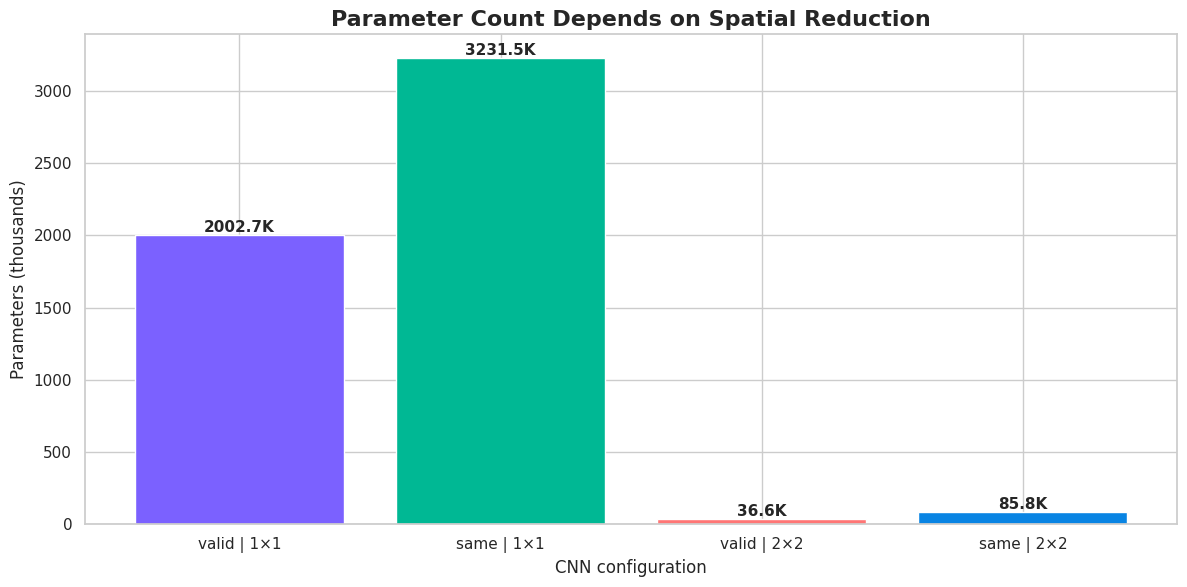

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    architecture_df["Padding"] + " | " + architecture_df["Stride"],
    architecture_df["Total params"] / 1e3,
    color=["#7B61FF", "#00B894", "#FF7675", "#0984E3"]
)

ax.set_title("Parameter Count Depends on Spatial Reduction", fontweight="bold")
ax.set_ylabel("Parameters (thousands)")
ax.set_xlabel("CNN configuration")

for bar, value in zip(bars, architecture_df["Total params"] / 1e3):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.1f}K",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [13]:
FAST_RUN = True

train_n = 12000 if FAST_RUN else len(X_train)
test_n = 3000 if FAST_RUN else len(X_test)

Xtr, ytr = X_train[:train_n], y_train[:train_n]
Xte, yte = X_test[:test_n], y_test[:test_n]

reference_model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, padding="same", strides=1, activation="relu", name="conv_same_1"),
    layers.BatchNormalization(),
    layers.Conv2D(32, 3, padding="same", strides=1, activation="relu", name="conv_same_2"),
    layers.MaxPooling2D(pool_size=2, strides=2, name="pool_1"),
    layers.Conv2D(64, 3, padding="same", strides=1, activation="relu", name="conv_same_3"),
    layers.MaxPooling2D(pool_size=2, strides=2, name="pool_2"),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(10, activation="softmax")
])

reference_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

reference_model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_same_1 (Conv2D)            │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_same_2 (Conv2D)            │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_same_3 (Conv2D)            │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431,018 (1.64 MB)

 Trainable params: 430,954 (1.64 MB)

 Non-trainable params: 64 (256.00 B)

In [14]:
history = reference_model.fit(
    Xtr, ytr,
    validation_split=0.1,
    epochs=5,
    batch_size=128,
    verbose=1
)

Epoch 1/5
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.8470 - loss: 0.4881 - val_accuracy: 0.9550 - val_loss: 1.6223
Epoch 2/5
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9642 - loss: 0.1191 - val_accuracy: 0.9725 - val_loss: 1.1733
Epoch 3/5
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9756 - loss: 0.0784 - val_accuracy: 0.9750 - val_loss: 0.5613
Epoch 4/5
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9805 - loss: 0.0593 - val_accuracy: 0.9817 - val_loss: 0.2997
Epoch 5/5
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9856 - loss: 0.0438 - val_accuracy: 0.9783 - val_loss: 0.1355


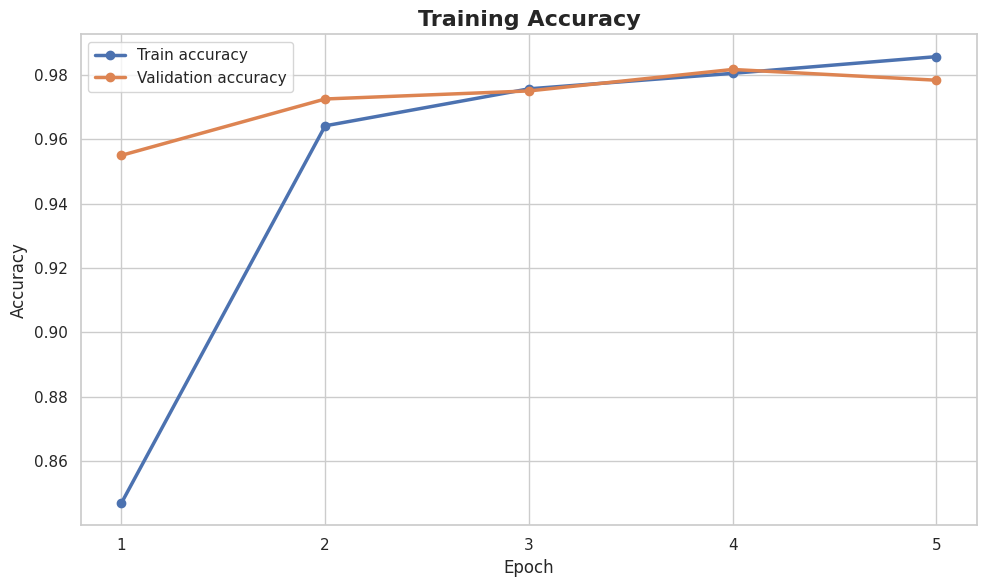

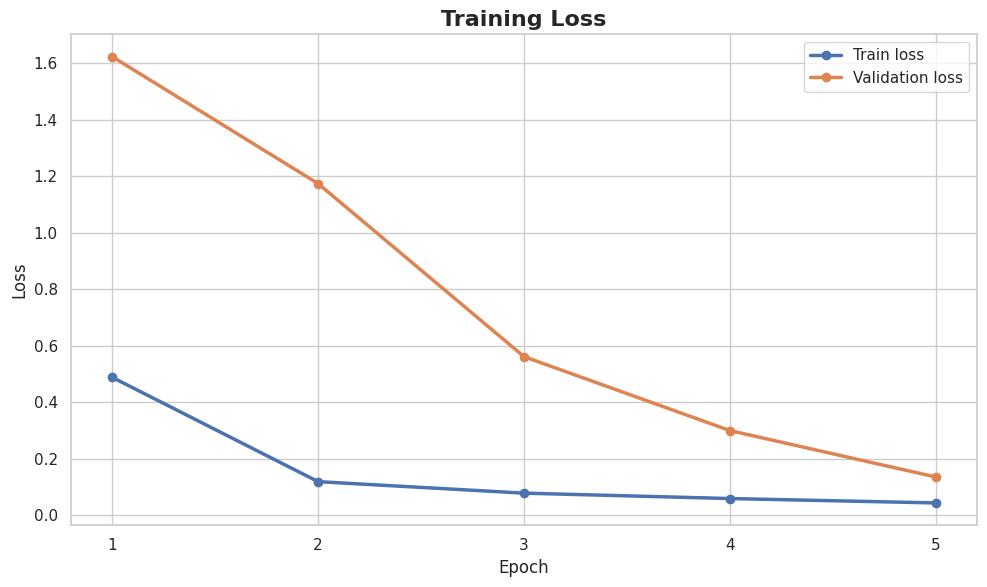

In [15]:
history_df = pd.DataFrame(history.history)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(history_df.index + 1, history_df["accuracy"], marker="o", linewidth=2.5, label="Train accuracy")
ax.plot(history_df.index + 1, history_df["val_accuracy"], marker="o", linewidth=2.5, label="Validation accuracy")
ax.set_title("Training Accuracy", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_xticks(history_df.index + 1)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(history_df.index + 1, history_df["loss"], marker="o", linewidth=2.5, label="Train loss")
ax.plot(history_df.index + 1, history_df["val_loss"], marker="o", linewidth=2.5, label="Validation loss")
ax.set_title("Training Loss", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_xticks(history_df.index + 1)
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
test_loss, test_acc = reference_model.evaluate(Xte, yte, verbose=0)
print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.4%}")

Test loss     : 0.1574
Test accuracy : 97.1333%


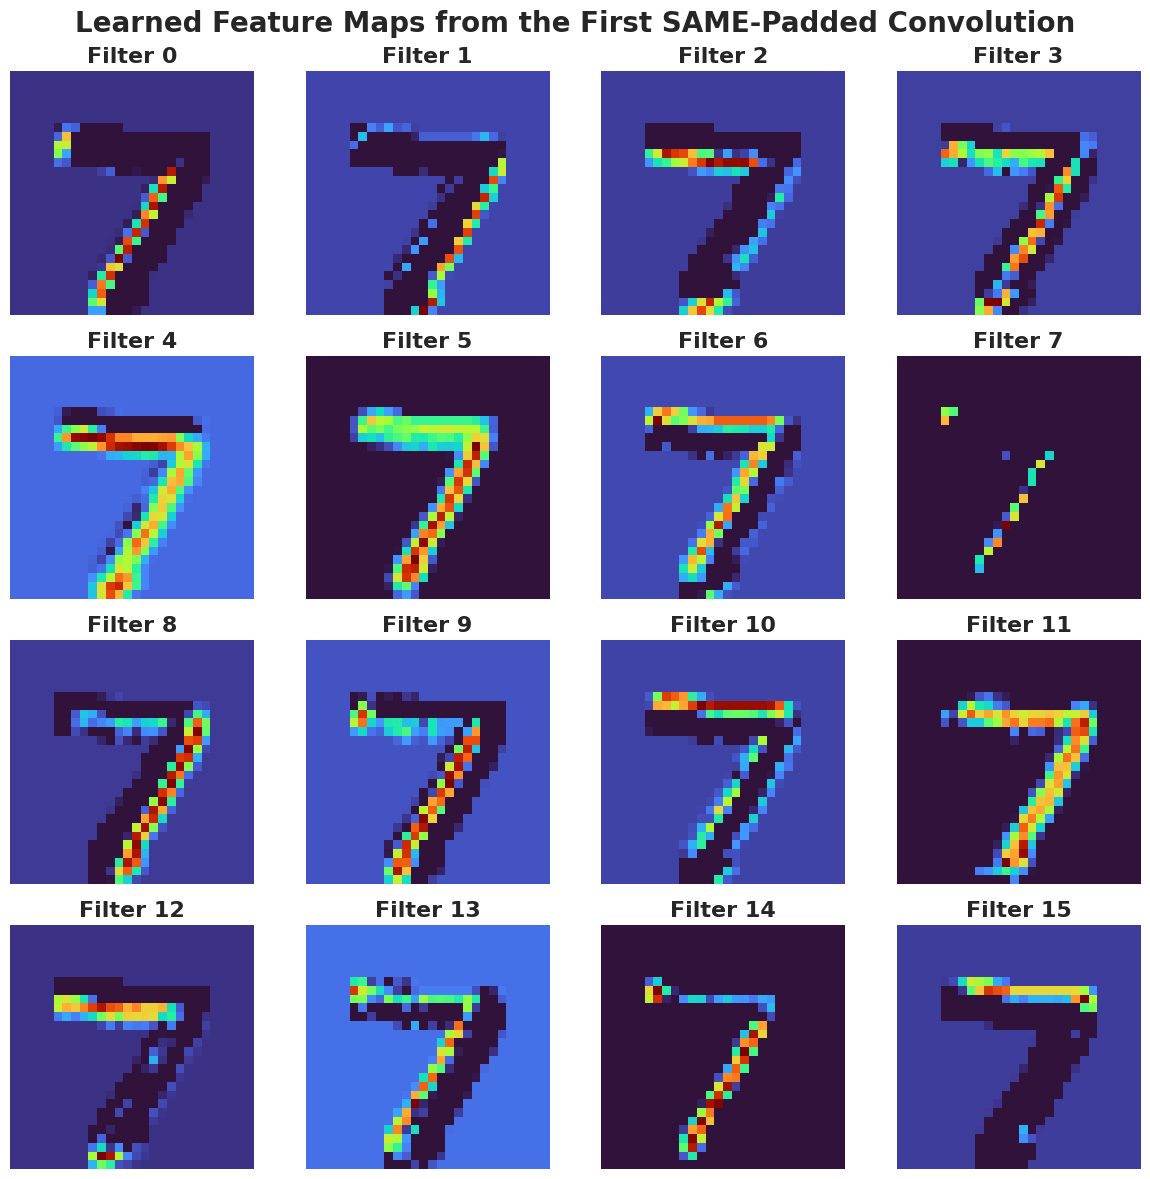

In [17]:
# We can reconstruct the extraction path functionally to avoid referencing Sequential.input directly
x_in = keras.Input(shape=(28, 28, 1))
x_out = reference_model.get_layer("conv_same_1")(x_in)

feature_extractor = keras.Model(inputs=x_in, outputs=x_out)
feature_maps = feature_extractor.predict(Xte[:1], verbose=0)[0]

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(feature_maps[:, :, i], cmap="turbo")
    ax.set_title(f"Filter {i}", fontweight="bold")
    ax.axis("off")

fig.suptitle("Learned Feature Maps from the First SAME-Padded Convolution", fontsize=20, fontweight="bold")
plt.tight_layout()
plt.show()

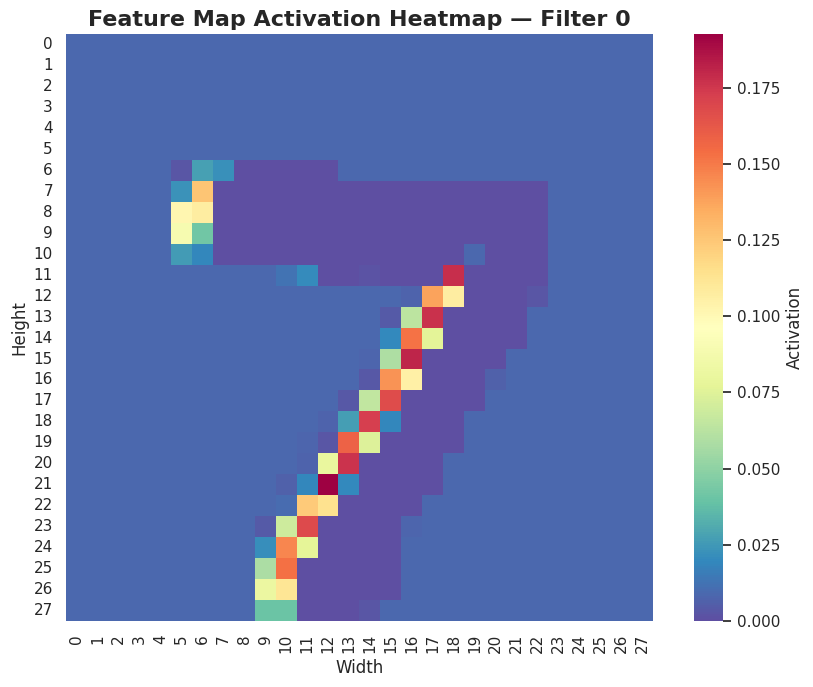

In [18]:
activation = feature_maps[:, :, 0]

plt.figure(figsize=(9, 7))
sns.heatmap(activation, cmap="Spectral_r", square=True, cbar_kws={"label": "Activation"})
plt.title("Feature Map Activation Heatmap — Filter 0", fontweight="bold")
plt.xlabel("Width")
plt.ylabel("Height")
plt.tight_layout()
plt.show()

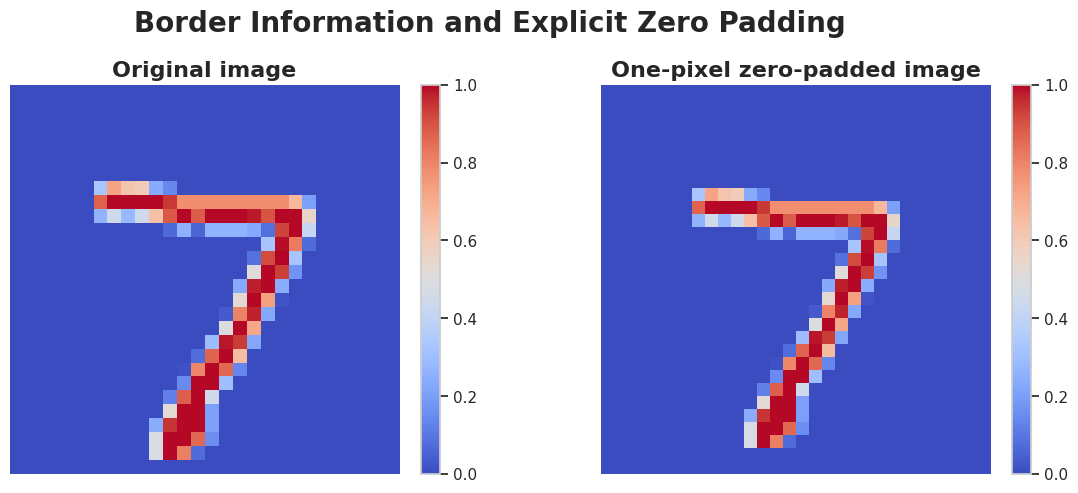

In [19]:
border_demo = Xte[0].squeeze()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, title, arr in [
    (axes[0], "Original image", border_demo),
    (axes[1], "One-pixel zero-padded image", np.pad(border_demo, 1))
]:
    im = ax.imshow(arr, cmap="coolwarm")
    ax.set_title(title, fontweight="bold")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Border Information and Explicit Zero Padding", fontsize=20, fontweight="bold")
plt.tight_layout()
plt.show()

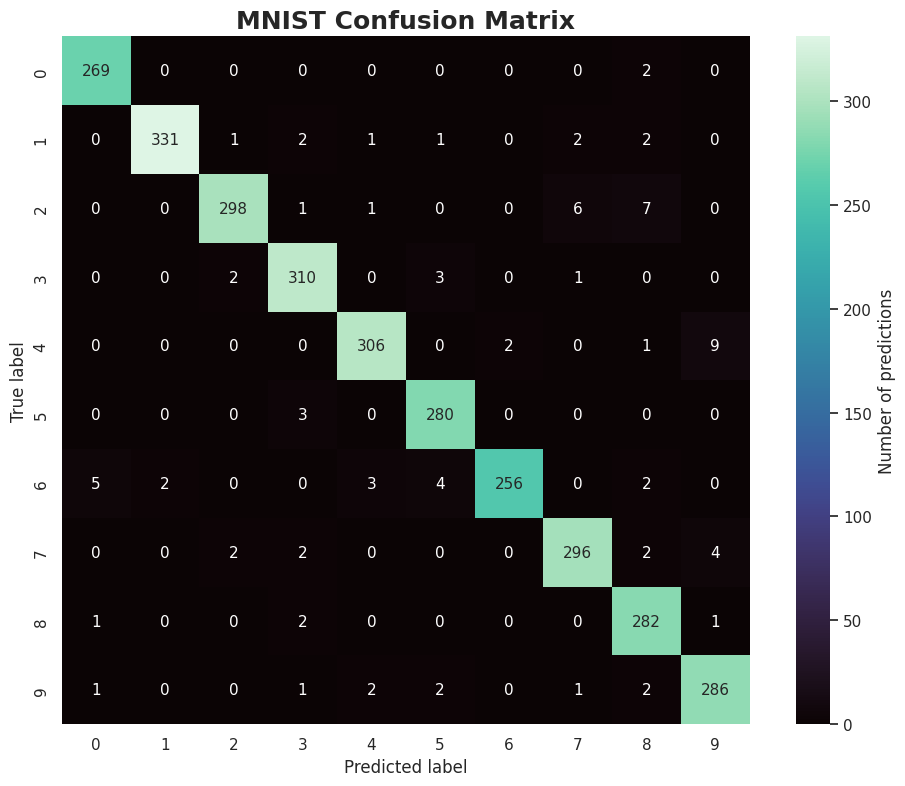

              precision    recall  f1-score   support

           0     0.9746    0.9926    0.9835       271
           1     0.9940    0.9735    0.9837       340
           2     0.9835    0.9521    0.9675       313
           3     0.9657    0.9810    0.9733       316
           4     0.9776    0.9623    0.9699       318
           5     0.9655    0.9894    0.9773       283
           6     0.9922    0.9412    0.9660       272
           7     0.9673    0.9673    0.9673       306
           8     0.9400    0.9860    0.9625       286
           9     0.9533    0.9695    0.9613       295

    accuracy                         0.9713      3000
   macro avg     0.9714    0.9715    0.9712      3000
weighted avg     0.9717    0.9713    0.9713      3000



In [20]:
pred_probs = reference_model.predict(Xte, verbose=0)
y_pred = np.argmax(pred_probs, axis=1)

cm = confusion_matrix(yte, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="mako",
    square=True,
    cbar_kws={"label": "Number of predictions"}
)
plt.title("MNIST Confusion Matrix", fontsize=18, fontweight="bold")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

print(classification_report(yte, y_pred, digits=4))

In [21]:
# One-cell summary of the core geometry rules

summary = pd.DataFrame([
    ["28×28", "3×3", "valid", 1, "26×26"],
    ["28×28", "3×3", "same", 1, "28×28"],
    ["28×28", "3×3", "valid", 2, "13×13"],
    ["28×28", "3×3", "same", 2, "14×14"],
], columns=["Input", "Kernel", "Padding", "Stride", "Output"])

summary


,Input,Kernel,Padding,Stride,Output
0,28×28,3×3,valid,1,26×26
1,28×28,3×3,same,1,28×28
2,28×28,3×3,valid,2,13×13
3,28×28,3×3,same,2,14×14
